# ¿Cuánto vale la promesa de pago de tu contraparte?
### Demo en vivo · CVA, DVA y *machine learning* sobre la TIIE de Fondeo

### Maurilio Patiño García
**Universidad Anáhuac · Maestría en Riesgo**

Vamos a construir, de cero y en vivo, la cadena completa: simular la curva mexicana, medir la
exposición, ponerle precio al riesgo de contraparte, ver su espejo (DVA), combinarlos en el ajuste bilateral
y, al final, entrenar un sustituto del motor mucho más rápido, sobre todo al valuar en lote.

> **Simplificaciones de la demo:** curva plana, pagos trimestrales, exposición descontada con la curva de
> mercado y *spreads* supuestos. Las cifras son **ilustrativas**: sirven para ver órdenes de magnitud, no son
> resultados finales de la tesis. La exposición se evalúa en las fechas de pago, donde la fórmula de la
> pata flotante es exacta (no queda cupón devengado sin contar). Eso no elimina el error de integración temporal de la
> malla trimestral.

### Apunte · El problema y los datos

- **Instrumento.** *Swap payer* (pagamos la tasa fija $K$ y recibimos TIIE de Fondeo), plazo
  $T = 5$ años, pagos trimestrales ($\delta = 0.25$), nocional $N_{\text{noc}} = 10$ MM MXN.
- **Modelo de tasas.** G2++ con los parámetros calibrados en la tesis: reversiones $a$ y $b$,
  volatilidades $\sigma$ y $\eta$, y correlación $\rho$ entre factores.
- **Curva inicial.** Plana, con forward instantáneo $f_0 = 7.10\%$ en capitalización continua. Con
  curva plana, el factor de descuento de mercado es $P^M(0,t) = e^{-f_0 t}$.
- **Crédito.** Recuperación $R = 25\%$ (convención de CDS para mercados emergentes); los *spreads*
  de CDS de las contrapartes son ilustrativos.
- **Malla.** Se monitorea la exposición en las fechas de pago $t_1, \dots, t_{19}$; al vencimiento
  la exposición es cero.

**Arquitectura: simular una vez y valuar todo.** Las trayectorias se generan una sola vez; la
exposición, el CVA, el DVA, los escenarios y las etiquetas del *machine learning* reutilizan ese
mismo conjunto de simulaciones.

La celda siguiente sólo fija parámetros y construye las fechas.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4.2), 'axes.grid': True, 'grid.alpha': .25})

# --- G2++ calibrado en la tesis a swaptions ATM (Bloomberg SWPM, 24-mar-2026) ---
a, b   = 0.148849, 0.982642      # reversión: factor lento (≈ nivel) / rápido (≈ pendiente)
sigma, eta = 0.026973, 0.062209  # volatilidades
rho    = -0.913918               # correlación entre factores
f0, R  = 0.0710, 0.25            # nivel de la curva plana (supuesto) | recuperación (convención CDS emergentes)
Noc    = 10_000_000              # nocional: 10 MM MXN
T, delta = 5.0, 0.25             # swap payer 5Y, pagos trimestrales

pay = np.arange(delta, T + 1e-9, delta)   # fechas de pago
mon = pay[:-1]                            # fechas de monitoreo = fechas de pago (sin omitir cupón devengado)
M, dt = len(pay), delta
print(f"Swap payer {T:.0f}Y · nocional {Noc:,} MXN · {M} pagos trimestrales")

Swap payer 5Y · nocional 10,000,000 MXN · 20 pagos trimestrales


---
## 1 · Simular el futuro
$r(t) = x(t) + y(t) + \varphi(t)$: dos factores gaussianos correlacionados. Cada factor se simula en forma **exacta**
(sin error de discretización). La correlación entre innovaciones se aproxima con $\rho$; con pasos
trimestrales la correlación exacta es $0.998\,\rho$, un efecto despreciable. El error relevante es el de Monte Carlo.

### Apunte · El modelo G2++ y su simulación

**Tasa corta.** Es la suma de dos factores gaussianos y una función determinista:

$$r(t) = x(t) + y(t) + \varphi(t), \qquad x(0) = y(0) = 0,$$

$$dx(t) = -a\,x(t)\,dt + \sigma\,dW_1(t), \qquad dy(t) = -b\,y(t)\,dt + \eta\,dW_2(t), \qquad dW_1\,dW_2 = \rho\,dt.$$

Bajo la medida neutral al riesgo, $x$ y $y$ son procesos de Ornstein-Uhlenbeck con media cero. Con
$a$ pequeña, $x$ persiste; con $b$ grande, $y$ se disipa rápido.

**Ajuste a la curva inicial.** $\varphi(t)$ hace que el modelo reproduzca la curva de hoy
(Brigo y Mercurio, 2006):

$$\varphi(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}\left(1-e^{-at}\right)^2 + \frac{\eta^2}{2b^2}\left(1-e^{-bt}\right)^2 + \rho\,\frac{\sigma\eta}{ab}\left(1-e^{-at}\right)\left(1-e^{-bt}\right).$$

En esta demo, $f^M(0,t) = f_0$.

**Simulación exacta por factor.** La transición de un proceso de Ornstein-Uhlenbeck es gaussiana,
así que para cualquier paso $\Delta$:

$$x(t+\Delta) = x(t)\,e^{-a\Delta} + \sigma\sqrt{\frac{1-e^{-2a\Delta}}{2a}}\;Z_1, \qquad y(t+\Delta) = y(t)\,e^{-b\Delta} + \eta\sqrt{\frac{1-e^{-2b\Delta}}{2b}}\;Z_2,$$

$$Z_2 = \rho\,Z_1 + \sqrt{1-\rho^2}\;Z, \qquad Z_1, Z \sim N(0,1) \text{ independientes}.$$

La media y la varianza de cada factor son exactas. La correlación entre $Z_1$ y $Z_2$ usa $\rho$;
la correlación exacta de los incrementos es ligeramente menor en magnitud ($0.998\,\rho$ con pasos
trimestrales), un efecto despreciable.

**Algoritmo** (`phi` y `simular`):
1. `phi(t)` evalúa la fórmula de $\varphi(t)$.
2. `simular(N, seed)` crea matrices de $N$ escenarios por $M+1$ fechas para $x$ y $y$, que empiezan
   en cero.
3. En cada paso genera $Z_1$ y $Z_2$ correlacionadas y aplica la transición exacta.
4. La gráfica muestra $r(t)$ con bandas entre los percentiles 1 y 99, 5 y 95, y 25 y 75, la mediana
   y 15 trayectorias individuales.

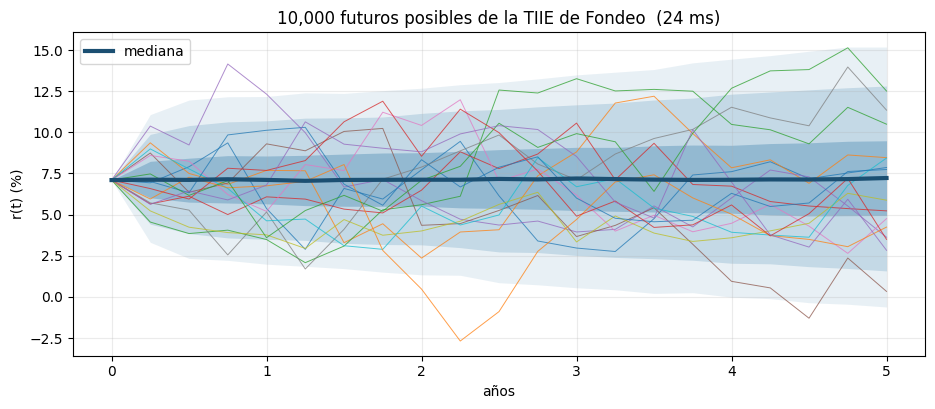

In [2]:
def phi(t):
    """φ(t) del G2++: forward instantáneo de mercado (curva plana f0) más el ajuste de convexidad
    que hace que el modelo reproduzca la curva inicial (Brigo y Mercurio, 2006)."""
    ea, eb = 1 - np.exp(-a*t), 1 - np.exp(-b*t)
    return (f0 + sigma**2/(2*a**2)*ea**2 + eta**2/(2*b**2)*eb**2
               + rho*sigma*eta/(a*b)*ea*eb)

def simular(N=10_000, seed=42):
    """Simula N trayectorias de (x, y) en las fechas de pago con la transición exacta de cada factor.
    Regresa dos matrices N x (M+1); la columna 0 corresponde a t = 0."""
    rng = np.random.default_rng(seed)
    x = np.zeros((N, M+1)); y = np.zeros((N, M+1))
    sx = sigma*np.sqrt((1-np.exp(-2*a*dt))/(2*a))
    sy = eta  *np.sqrt((1-np.exp(-2*b*dt))/(2*b))
    for i in range(M):
        z1 = rng.standard_normal(N)
        z2 = rho*z1 + np.sqrt(1-rho**2)*rng.standard_normal(N)
        x[:, i+1] = x[:, i]*np.exp(-a*dt) + sx*z1
        y[:, i+1] = y[:, i]*np.exp(-b*dt) + sy*z2
    return x, y

t0 = time.perf_counter(); x, y = simular(); t_sim = time.perf_counter() - t0
tt = np.concatenate([[0.0], pay])
r = x + y + phi(tt)                      # tasa corta r = x + y + φ(t)

fig, ax = plt.subplots()
for q, al in [(1, .10), (5, .18), (25, .30)]:
    ax.fill_between(tt, np.percentile(100*r, q, axis=0), np.percentile(100*r, 100-q, axis=0),
                    color='#2471a3', alpha=al, lw=0)
ax.plot(tt, 100*r[:15].T, lw=.7, alpha=.75)
ax.plot(tt, np.median(100*r, axis=0), color='#1b4f72', lw=3, label='mediana')
ax.set(xlabel='años', ylabel='r(t) (%)', title=f'10,000 futuros posibles de la TIIE de Fondeo  ({t_sim*1000:.0f} ms)')
ax.legend(); plt.show()

> **Lectura.** El abanico se abre con la raíz del tiempo: a 5 años la banda del 90% cubre unos
> 11 puntos porcentuales. Eso **no** es un pronóstico de tasas: es la incertidumbre que el mercado
> le pone precio hoy, bajo la medida $\mathbb{Q}$. Las trayectorias individuales muestran la
> combinación de los dos factores: variaciones rápidas sobre un nivel que cambia lentamente.
>
> Estas trayectorias se simulan **una sola vez**. La
> exposición, el CVA, el DVA, los escenarios y el entrenamiento del modelo se calculan reusando
> este mismo cubo. *Simular una vez, valuar todo.*

---
## 2 · Valuar el swap en cada futuro
Fórmula cerrada del bono cupón cero del G2++. De aquí sale el **cubo de MtM**: cada trayectoria,
cada fecha, un valor.

### Apunte · El bono cupón cero del G2++ y el valor del *swap*

**Precio del bono.** Dado el estado $(x(t), y(t))$, el precio en $t$ de un bono que paga 1 en $T$ es
(Brigo y Mercurio, 2006):

$$P(t,T) = \frac{P^M(0,T)}{P^M(0,t)}\exp\left\{\tfrac12\left[V(t,T) - V(0,T) + V(0,t)\right] - B_a(T-t)\,x(t) - B_b(T-t)\,y(t)\right\}, \qquad B_k(\tau) = \frac{1-e^{-k\tau}}{k}.$$

$V(t,T)$ es la varianza de $\int_t^T [x(u)+y(u)]\,du$ y sólo depende de $\tau = T-t$:

$$V(\tau) = \frac{\sigma^2}{a^2}\left[\tau + \frac{2}{a}e^{-a\tau} - \frac{1}{2a}e^{-2a\tau} - \frac{3}{2a}\right] + \frac{\eta^2}{b^2}\left[\tau + \frac{2}{b}e^{-b\tau} - \frac{1}{2b}e^{-2b\tau} - \frac{3}{2b}\right] + 2\rho\,\frac{\sigma\eta}{ab}\left[\tau + \frac{e^{-a\tau}-1}{a} + \frac{e^{-b\tau}-1}{b} - \frac{e^{-(a+b)\tau}-1}{a+b}\right].$$

Con curva plana, $P^M(0,T)/P^M(0,t) = e^{-f_0 (T-t)}$.

**Valor del *swap payer*.** En una fecha de pago $t_i$, ya liquidado el pago de esa fecha, con los
pagos restantes $T_j > t_i$:

$$V(t_i) = N_{\text{noc}}\Big[\underbrace{1 - P(t_i, T_n)}_{\text{pata flotante}} - K\,\underbrace{\delta \sum_{T_j > t_i} P(t_i, T_j)}_{\text{anualidad } A(t_i)}\Big].$$

La pata flotante vale $1 - P(t_i, T_n)$ sólo en fechas de pago; entre pagos faltaría el cupón ya
devengado. Por eso la malla coincide con las fechas de pago.

**Tasa fija ATM.** Es la que hace que el *swap* valga cero hoy:

$$K_{\text{ATM}} = \frac{1 - P(0, T_n)}{\delta \sum_j P(0, T_j)}.$$

**Exposiciones.** Sobre los $N$ escenarios $k$, en cada fecha $t_i$:

$$\mathrm{EE}(t_i) = \frac{1}{N}\sum_{k} \max\big(V_k(t_i), 0\big), \qquad \mathrm{ENE}(t_i) = \frac{1}{N}\sum_{k} \max\big(-V_k(t_i), 0\big),$$

y $\mathrm{PFE}(t_i)$ es el percentil 97.5 de $\max(V_k(t_i), 0)$.

**Algoritmo:**
1. Para cada fecha de monitoreo, evalúa $P(t_i, T_j)$ en todos los escenarios y en todos los pagos
   restantes.
2. Guarda sólo dos vectores por fecha: $P(t_i, T_n)$ y la anualidad $A(t_i)$. Con ellos se revalúa el
   *swap* para cualquier tasa fija $K$ sin volver a simular. Ése es el **cubo** que reutilizan las
   secciones siguientes.
3. Calcula $V$, EE, ENE y PFE.

El factor $\mathrm{DF}(t) = P^M(0,t) = e^{-f_0 t}$ se usa al agregar el CVA (sección 3).

In [3]:
def B(k, tau):
    """B_k(τ) = (1 − e^{−kτ})/k: sensibilidad del bono a un factor con reversión k."""
    return (1 - np.exp(-k*tau)) / k

def Vv(tau):
    """V(τ): varianza de la integral de (x + y) en un horizonte τ (Brigo y Mercurio, 2006)."""
    tau = np.maximum(tau, 0)
    return ((sigma**2/a**2)*(tau + (2/a)*np.exp(-a*tau) - (1/(2*a))*np.exp(-2*a*tau) - 3/(2*a))
          + (eta**2 /b**2)*(tau + (2/b)*np.exp(-b*tau) - (1/(2*b))*np.exp(-2*b*tau) - 3/(2*b))
          + 2*rho*(sigma*eta/(a*b))*(tau + (np.exp(-a*tau)-1)/a + (np.exp(-b*tau)-1)/b
                                         - (np.exp(-(a+b)*tau)-1)/(a+b)))

def P(ti, Tj, xi, yi):
    """Bono cupón cero P(t_i, T_j) del G2++ dado el estado (x, y); vectorizado sobre escenarios.
    Con curva plana, P^M(0,T)/P^M(0,t) = exp(−f0·τ); el término 0.5·(...) es la corrección de convexidad."""
    tau = Tj - ti
    return np.exp(-f0*tau + 0.5*(Vv(tau) - Vv(Tj) + Vv(ti)) - B(a,tau)*xi - B(b,tau)*yi)

P0    = np.array([P(0, Tj, 0, 0) for Tj in pay])
K_atm = (1 - P0[-1]) / (delta * P0.sum())          # tasa fija ATM
DF    = np.exp(-f0 * mon)

t0 = time.perf_counter()
Pn_l, ann_l = [], []
for j, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, x[:, j], y[:, j]) for Tj in rem], axis=1)
    Pn_l.append(Pm[:, -1]); ann_l.append(delta * Pm.sum(axis=1))
t_val = time.perf_counter() - t0

V   = [Noc*((1 - Pn) - K_atm*an) for Pn, an in zip(Pn_l, ann_l)]   # MtM por fecha
EE  = np.array([np.maximum( v, 0).mean() for v in V])              # exposición esperada
ENE = np.array([np.maximum(-v, 0).mean() for v in V])              # exposición negativa
PFE = np.array([np.percentile(np.maximum(v, 0), 97.5) for v in V])
print(f"Tasa fija ATM: {K_atm:.4%}   |   cubo de MtM valuado en {t_val*1000:.0f} ms")

Tasa fija ATM: 7.1634%   |   cubo de MtM valuado en 38 ms


> **Lectura.** La tasa fija ATM sale en **7.16%**, ligeramente por encima del nivel de la curva
> (7.10%, en capitalización continua): es la conversión a pagos trimestrales. En $t=0$ los precios
> no dependen de los parámetros del G2++. Con esa tasa el *swap* vale cero hoy; después, su valor cambia con las tasas.
>
> Valuar 10,000 trayectorias × 19 fechas × todos los flujos toma **decenas de milisegundos**.
> Ese orden de magnitud es el costo que, en un libro, se multiplica por cientos de operaciones
> y por decenas de perturbaciones.

### Una sola distribución, partida por el cero
En el pico de exposición, miramos el valor del *swap* sobre las 10,000 trayectorias. **La mitad
derecha alimenta el CVA; la mitad izquierda alimenta el DVA.** Es la misma simulación leída desde
los dos lados.

### Apunte · La distribución en el pico

Se toma la fecha $t^*$ en la que EE es máxima y se grafica el histograma de $V_k(t^*)$ sobre los
10,000 escenarios.

- La parte positiva (rojo) es lo que la contraparte nos debería: alimenta el CVA.
- La parte negativa (azul) es lo que le deberíamos: alimenta el DVA.
- Las líneas punteadas marcan $\mathrm{EE}(t^*)$ y $-\mathrm{ENE}(t^*)$.

EE promedia sobre **todos** los escenarios, con cero en los negativos; por eso queda por debajo de
la media de los valores positivos.

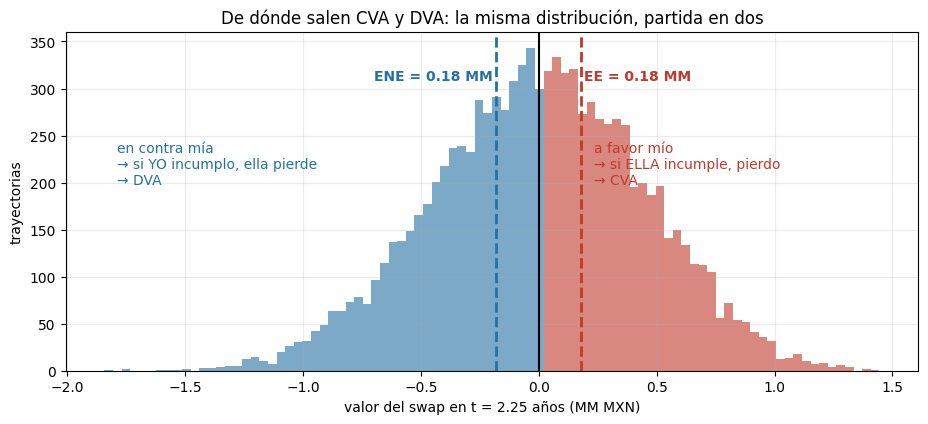

In [4]:
j  = int(EE.argmax()); Vp = V[j]/1e6
fig, ax = plt.subplots(figsize=(11, 4.4))
n, bins, patches = ax.hist(Vp, bins=90, edgecolor='none')
for p, bl in zip(patches, bins[:-1]):
    p.set_facecolor('#c0392b' if bl >= 0 else '#2471a3'); p.set_alpha(.6)
ax.axvline(0, color='k', lw=1.5)
ax.axvline( EE[j]/1e6, color='#c0392b', ls='--', lw=2)
ax.axvline(-ENE[j]/1e6, color='#2471a3', ls='--', lw=2)
ax.text( EE[j]/1e6*1.08, max(n)*.90, f'EE = {EE[j]/1e6:.2f} MM', color='#c0392b', fontweight='bold')
ax.text(-ENE[j]/1e6*1.08, max(n)*.90, f'ENE = {ENE[j]/1e6:.2f} MM', color='#2471a3',
        fontweight='bold', ha='right')
ax.text(.62, .55, 'a favor mío\n→ si ELLA incumple, pierdo\n→ CVA', transform=ax.transAxes,
        color='#c0392b', fontsize=10)
ax.text(.06, .55, 'en contra mía\n→ si YO incumplo, ella pierde\n→ DVA', transform=ax.transAxes,
        color='#2471a3', fontsize=10)
ax.set(xlabel=f'valor del swap en t = {mon[j]:.2f} años (MM MXN)', ylabel='trayectorias',
       title='De dónde salen CVA y DVA: la misma distribución, partida en dos')
plt.show()

> **Un solo objeto, dos riesgos.** El *swap* está *at-the-money* y, en este ejemplo, la distribución
> resulta aproximadamente centrada en cero (estar ATM hoy no lo garantiza en general): es casi
> igual de probable que valga a mi favor o en mi contra.
>
> - **Lado rojo** (a mi favor): ella me debe. Si incumple, **yo** pierdo → esto es el **CVA**.
> - **Lado azul** (en mi contra): yo le debo. Si incumplo, **ella** pierde → esto es el **DVA**.
>
> **Cómo se calcula EE:** conservamos los valores positivos, sustituimos los negativos por cero y
> promediamos **todos** los escenarios (no es la media de los valores positivos). ENE es el espejo.
> Por eso el DVA no requiere un modelo nuevo:
> es la misma simulación, el mismo cubo, leído desde la otra silla. Y por eso son casi iguales
> (0.18 MM cada uno): la asimetría del precio final vendrá **casi toda** de los *spreads* de crédito.
>
> Ambos lados nacen de un $\max(\cdot,0)$. Esa no-linealidad es la razón por la
> que el CVA de un portafolio con neteo **no** es la suma de los CVA individuales, y de ahí viene buena parte
> de la dificultad técnica de la tesis.

### Promediando cada lado en todas las fechas: los dos perfiles

### Apunte · Perfiles de exposición

Se grafican $\mathrm{EE}(t)$, $-\mathrm{ENE}(t)$ y la PFE en todas las fechas de monitoreo. Dos
efectos dan la forma de joroba:

- la dispersión de las tasas crece con el horizonte, aproximadamente como $\sqrt{t}$;
- la duración remanente del *swap* disminuye hasta cero al vencimiento (efecto de amortización).

Una aproximación clásica (Gregory, 2012) da un perfil proporcional a $\sqrt{t}\,(T-t)$, cuyo
máximo está en $t = T/3$. La malla trimestral y la forma exacta del modelo mueven un poco ese
punto.

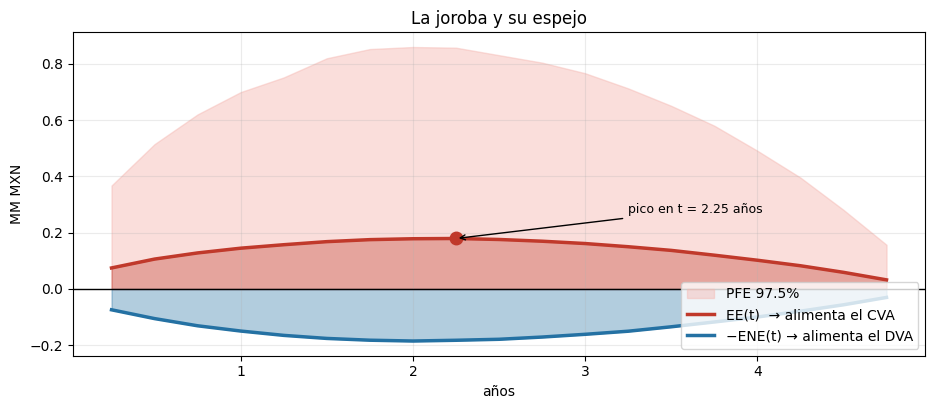

In [5]:
fig, ax = plt.subplots()
ax.fill_between(mon, 0, PFE/1e6, color='#f5b7b1', alpha=.45, label='PFE 97.5%')
ax.fill_between(mon, 0,  EE/1e6, color='#c0392b', alpha=.35)
ax.fill_between(mon, 0, -ENE/1e6, color='#2471a3', alpha=.35)
ax.plot(mon,  EE/1e6, color='#c0392b', lw=2.5, label='EE(t)  → alimenta el CVA')
ax.plot(mon, -ENE/1e6, color='#2471a3', lw=2.5, label='−ENE(t) → alimenta el DVA')
ax.axhline(0, color='k', lw=1)
ax.plot(mon[j], EE[j]/1e6, 'o', ms=9, color='#c0392b')
ax.annotate(f'pico en t = {mon[j]:.2f} años', xy=(mon[j], EE[j]/1e6), xytext=(mon[j]+1, EE[j]/1e6*1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set(xlabel='años', ylabel='MM MXN', title='La joroba y su espejo')
ax.legend(loc='lower right'); plt.show()

> **Lectura.** La **joroba** es el perfil típico de exposición de un *swap*: la exposición crece porque la
> incertidumbre sobre las tasas se acumula, y luego cae porque quedan menos flujos por intercambiar
> (efecto de amortización). El pico llega mucho antes del vencimiento: la aproximación clásica lo
> ubica cerca de **T/3** (Gregory, 2012); en esta demo, con malla trimestral, cae en la primera mitad de la vida.
>
> En este *swap*, la exposición esperada alcanza su máximo en la primera parte de su vida, no al
> vencimiento; por eso la exposición se revisa a lo largo de todo el horizonte.
>
> La PFE (banda rosa) es el percentil 97.5% de la exposición: un "peor caso razonable" que se usa
> para fijar líneas de crédito.

---
## 3 · Ponerle precio: CVA, DVA y el ajuste bilateral
$$\mathrm{CVA} = (1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}(t_i)\,\mathrm{DF}(t_i)
\qquad
\mathrm{DVA} = (1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}^{\text{propia}}(t_i)\,\mathrm{DF}(t_i)$$

La única diferencia entre ambos: **qué perfil usas y de quién es el *spread* de crédito.**

Supuestos: exposición independiente del incumplimiento. El valor del *swap* se calcula en cada
escenario con sus propias tasas; la exposición esperada se descuenta con la curva de mercado, lo que
omite la covarianza entre descuento y exposición (en la tesis, $+0.25\%$ en el *swap* de referencia). El ajuste
bilateral $\mathrm{DVA}-\mathrm{CVA}$ es **simplificado**: cada término usa las probabilidades
marginales de una sola parte y no modela cuál de las dos incumple primero (Gregory, 2012).

### Apunte · Del CDS a la probabilidad y al precio

**Intensidad de incumplimiento.** Se toma constante, con la aproximación del triángulo de crédito:

$$\lambda \approx \frac{s}{1-R}.$$

**Supervivencia y probabilidad marginal** en cada intervalo $(t_{i-1}, t_i]$, con $t_0 = 0$:

$$Q(t) = e^{-\lambda t}, \qquad \Delta\mathrm{PD}_i = Q(t_{i-1}) - Q(t_i).$$

**CVA y DVA discretizados**, en puntos base del nocional:

$$\mathrm{CVA} = \frac{10^4}{N_{\text{noc}}}\,(1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}_i^{\text{ella}}\,\mathrm{DF}(t_i), \qquad \mathrm{DVA} = \frac{10^4}{N_{\text{noc}}}\,(1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}_i^{\text{yo}}\,\mathrm{DF}(t_i),$$

$$\mathrm{BCVA} = \mathrm{DVA} - \mathrm{CVA}.$$

**Notas sobre la aproximación:**
- Cada intervalo usa la exposición al final del intervalo.
- $\mathrm{DF}(t_i) = P^M(0,t_i)$ multiplica la exposición promedio. La forma exacta es
  $\mathbb{E}[D(0,t)\,V^+(t)]$ con $D(0,t) = e^{-\int_0^t r(u)\,du}$; la diferencia es la covarianza
  entre descuento y exposición (en la tesis, $+0.25\%$ en el *swap* de referencia).
- Se usa la misma recuperación para ambas partes y una intensidad plana por contraparte; la tesis
  usa curvas de CDS por plazo.
- El BCVA así calculado no modela cuál de las dos partes incumple primero.

**Algoritmo** (`xva_bps(perfil, cds)`): calcula $\lambda$, $Q$ y $\Delta\mathrm{PD}$, y aplica la
suma. Con el perfil EE y el *spread* de ella da el CVA; con ENE y el *spread* propio, el DVA.

In [6]:
def xva_bps(perfil, cds_bps):
    """Ajuste (CVA o DVA) en bps del nocional: (1−R)·Σ perfil·ΔPD·DF, con intensidad plana s/(1−R)."""
    lam = cds_bps/1e4/(1 - R)                        # intensidad de default
    Q   = np.exp(-lam * mon)                         # curva de supervivencia
    dPD = -np.diff(np.concatenate([[1.0], Q]))       # probabilidad marginal
    return (1 - R) * np.sum(perfil * dPD * DF) / Noc * 1e4

cds_ella, cds_yo = 150.0, 80.0                       # ¡cámbienlos y vuelvan a correr!

cva  = xva_bps(EE,  cds_ella)
dva  = xva_bps(ENE, cds_yo)
bcva = dva - cva

print(f"  CVA  (ella, CDS {cds_ella:>5.0f} bps) = {cva:6.2f} bps = {cva/1e4*Noc:>10,.0f} MXN")
print(f"  DVA  (yo,   CDS {cds_yo:>5.0f} bps) = {dva:6.2f} bps = {dva/1e4*Noc:>10,.0f} MXN")
print(f"  {'-'*58}")
print(f"  BCVA = DVA − CVA           = {bcva:+6.2f} bps = {bcva/1e4*Noc:>+10,.0f} MXN")
print(f"\n  → {'Yo soy el riesgoso: el ajuste juega a mi favor.' if bcva > 0 else 'Ella es la riesgosa: el ajuste me cuesta a mí.'}")

  CVA  (ella, CDS   150 bps) =   7.65 bps =      7,650 MXN
  DVA  (yo,   CDS    80 bps) =   4.21 bps =      4,214 MXN
  ----------------------------------------------------------
  BCVA = DVA − CVA           =  -3.44 bps =     -3,436 MXN

  → Ella es la riesgosa: el ajuste me cuesta a mí.


> **Lectura.** Los perfiles eran casi simétricos, pero el precio **no** lo es: el CVA casi duplica
> al DVA. La causa principal es el crédito: ella cotiza a 150 bps y nosotros a 80.
>
> El **BCVA de −3.44 bps** (≈ 3,400 pesos sobre 10 MM) es el ajuste neto. En una cotización real,
> esos 3.4 bps se reflejan en el precio: los absorbe el margen o se trasladan al cliente.
>
> El DVA es **una ganancia contable que aumenta cuando el crédito propio se deteriora.** IFRS 13 incluye el riesgo de
> crédito propio al valuar pasivos (párrafo 42), pero esa ganancia es muy difícil de monetizar. En esa
> línea, Basilea excluye del capital CET1 los ajustes por crédito propio (CAP30.15) y el CVA regulatorio
> excluye el incumplimiento propio (MAR50.3). La tesis trabaja con CVA unilateral como **decisión de
> alcance**, no porque la norma lo exija.

### ¿Y luego? Se combinan, y quién gana depende de quién es más riesgoso
Recorremos **mi** *spread* de crédito de 0 a 400 bps dejando fijo el de ella: hay un punto de
cruce donde el ajuste bilateral cambia de signo.

### Apunte · El punto de equilibrio

Se deja fijo el *spread* de la contraparte y se recorre el propio de 0 a 400 bps en 60 puntos. El
CVA no cambia y el DVA crece con el *spread* propio, así que el BCVA cruza el cero en un punto
$s^*$, que se localiza por interpolación lineal sobre la malla (`np.interp`).

Si los perfiles EE y ENE fueran idénticos y la recuperación fuera la misma, $s^*$ coincidiría con el
*spread* de la contraparte.

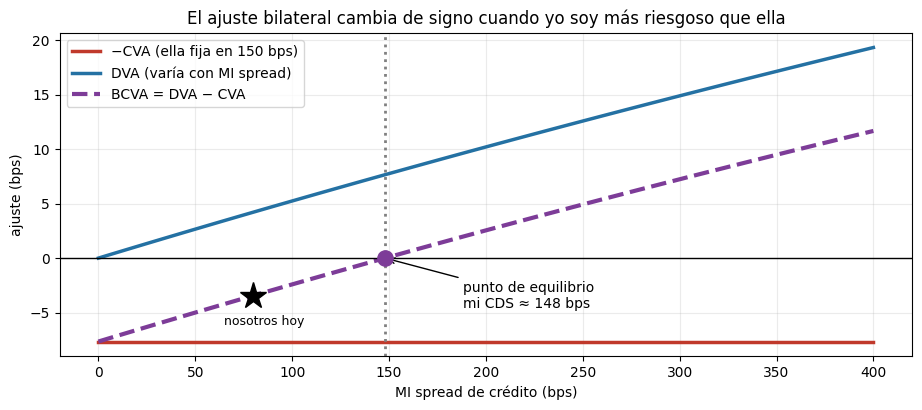

Por debajo de 148 bps el ajuste neto me cuesta; por encima, juega a mi favor.


In [7]:
spreads_yo = np.linspace(0, 400, 60)
cvas = np.full_like(spreads_yo, cva)
dvas = np.array([xva_bps(ENE, s) for s in spreads_yo])
bcvas = dvas - cvas

fig, ax = plt.subplots()
ax.plot(spreads_yo, -cvas, color='#c0392b', lw=2.5, label=f'−CVA (ella fija en {cds_ella:.0f} bps)')
ax.plot(spreads_yo,  dvas, color='#2471a3', lw=2.5, label='DVA (varía con MI spread)')
ax.plot(spreads_yo, bcvas, color='#7d3c98', lw=3, ls='--', label='BCVA = DVA − CVA')
ax.axhline(0, color='k', lw=1)
cruce = np.interp(0, bcvas, spreads_yo)
ax.axvline(cruce, color='gray', ls=':', lw=2)
ax.plot(cruce, 0, 'o', ms=11, color='#7d3c98', zorder=5)
ax.annotate(f'punto de equilibrio\nmi CDS ≈ {cruce:.0f} bps', xy=(cruce, 0), xytext=(cruce+40, -cva*0.6),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.plot(cds_yo, bcva, '*', ms=20, color='k', zorder=5)
ax.annotate('nosotros hoy', xy=(cds_yo, bcva), xytext=(cds_yo-15, bcva-cva*0.35), fontsize=9)
ax.set(xlabel='MI spread de crédito (bps)', ylabel='ajuste (bps)',
       title='El ajuste bilateral cambia de signo cuando yo soy más riesgoso que ella')
ax.legend(loc='upper left'); plt.show()
print(f"Por debajo de {cruce:.0f} bps el ajuste neto me cuesta; por encima, juega a mi favor.")

> **Lectura.** Aquí está la respuesta a "¿y luego, cómo se combinan?".
>
> Con el CDS de ella **fijo**, movemos el **mío**. El BCVA (línea morada) cruza el cero en
> ≈ **148 bps**, muy cerca del *spread* de ella (150): **como los dos perfiles son casi simétricos, el
> ajuste bilateral casi se anula cuando ambas partes tienen el mismo riesgo de crédito.** Dos
> contrapartes igualmente riesgosas, con exposiciones simétricas, se cobran casi lo mismo.
>
> - A la izquierda del cruce (nuestro caso, la estrella): **soy el más sólido**, así que el ajuste
>   me cuesta.
> - A la derecha: **yo soy el riesgoso**, y el ajuste juega a mi favor.
>
> Cuando dos instituciones que reconocen ambos ajustes negocian un *swap*, esta diferencia forma
> parte de la discusión del precio.

---
## 4 · El mismo swap, seis contrapartes
Mismo instrumento y mismo nocional; sólo cambia la contraparte. Los *spreads* son ilustrativos.

### Apunte · Sensibilidad al crédito de la contraparte

Con el mismo perfil EE, se calcula el CVA para seis *spreads* ilustrativos. Para *spreads*
moderados, el CVA es casi proporcional al *spread*: $\Delta\mathrm{PD}_i \approx \lambda\,\Delta t\,e^{-\lambda t_i}$
y $(1-R)\,\lambda \approx s$, así que la recuperación casi se cancela. Con *spreads* altos, la
supervivencia cae más rápido y la relación deja de ser lineal.

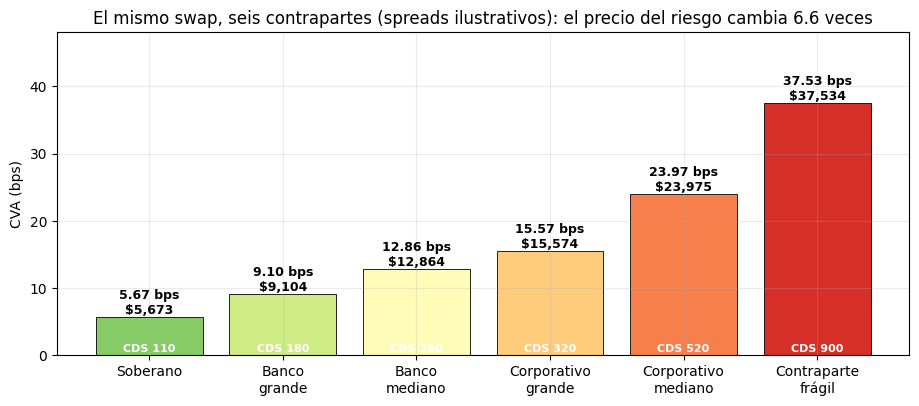

In [8]:
cps = [('Soberano', 110), ('Banco\ngrande', 180), ('Banco\nmediano', 260),
       ('Corporativo\ngrande', 320), ('Corporativo\nmediano', 520), ('Contraparte\nfrágil', 900)]
vals = [xva_bps(EE, s) for _, s in cps]

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar([c[0] for c in cps], vals, edgecolor='k', lw=.6,
              color=plt.cm.RdYlGn_r(np.linspace(.25, .9, len(cps))))
for bar, v, (_, s) in zip(bars, vals, cps):
    xc = bar.get_x() + bar.get_width()/2
    ax.text(xc, v + .5, f'{v:.2f} bps\n${v/1e4*Noc:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xc, .6, f'CDS {s}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set(ylabel='CVA (bps)', ylim=(0, max(vals)*1.28),
       title='El mismo swap, seis contrapartes (spreads ilustrativos): el precio del riesgo cambia '
             f'{max(vals)/min(vals):.1f} veces')
plt.show()

> **Lectura.** Mismo instrumento, mismo nocional, misma fecha. Sólo cambia la contraparte, y el precio
> se mueve **casi 7 veces**, de 5.7 a 37.5 bps.
>
> En pesos, la diferencia entre la contraparte soberana y la frágil es de unos **32,000 pesos**
> sobre una operación de 10 millones.
>
> El riesgo de crédito de la contraparte tiene un precio, y en este ejemplo es material.

---
## 5 · Por qué el motor es caro: el error cae como $1/\sqrt{N}$
Para ganar un decimal hay que multiplicar por 100 el número de trayectorias. Eso es lo que
vuelve tan costoso recalcular un libro entero muchas veces al día.

### Apunte · El error de Monte Carlo

EE es un promedio de $N$ escenarios, así que su desviación estándar decrece como $\sigma_V/\sqrt{N}$.
Para verlo, el código repite el cálculo completo del CVA con cinco semillas distintas para cada
$N \in \{250, 500, \dots, 16{,}000\}$ y grafica la media $\pm$ dos desviaciones estándar entre
semillas.

Pasar de 250 a 16,000 trayectorias (64 veces más) debería reducir la dispersión unas ocho veces
($\sqrt{64}$). Con sólo cinco semillas por punto, la dispersión estimada es ruidosa.

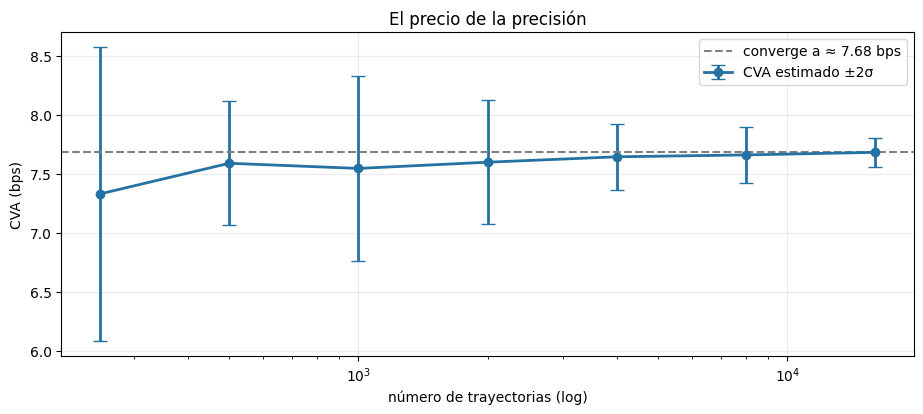

In [9]:
Ns = [250, 500, 1000, 2000, 4000, 8000, 16000]
est, sd = [], []
for N in Ns:
    v = []
    for s in range(5):
        xs, ys = simular(N=N, seed=100+s)
        Pn_s, an_s = [], []
        for jj, ti in enumerate(mon, start=1):
            rem = pay[pay > ti + 1e-9]
            Pm  = np.stack([P(ti, Tj, xs[:, jj], ys[:, jj]) for Tj in rem], axis=1)
            Pn_s.append(Pm[:, -1]); an_s.append(delta*Pm.sum(axis=1))
        EEs = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_s, an_s)])
        v.append(xva_bps(EEs, cds_ella))
    est.append(np.mean(v)); sd.append(np.std(v))
est, sd = np.array(est), np.array(sd)

fig, ax = plt.subplots()
ax.errorbar(Ns, est, yerr=2*sd, fmt='o-', capsize=5, lw=2, color='#2471a3', label='CVA estimado ±2σ')
ax.axhline(est[-1], ls='--', color='gray', label=f'converge a ≈ {est[-1]:.2f} bps')
ax.set_xscale('log')
ax.set(xlabel='número de trayectorias (log)', ylabel='CVA (bps)',
       title='El precio de la precisión')
ax.legend(); plt.show()

> **Lectura.** Con 250 trayectorias el CVA es **poco preciso** (±0.6 bps de dispersión sobre un
> valor de 7.7). Con 16,000 ya es estable, pero cuesta 64 veces más cómputo.
>
> Es la convergencia $1/\sqrt{N}$: **para ganar un decimal hay que multiplicar el trabajo por
> 100.**
>
> Las barras de error **nunca llegan a cero**: incluso el "número exacto" del motor es
> un estimador con ruido. Cuando más adelante comparemos el ML contra el Monte Carlo, hay que
> recordar que el patrón de referencia tampoco es perfecto.

---
## 6 · El sustituto: *machine learning* que aprende del propio motor
Las etiquetas **no requieren etiquetado manual** y salen baratas: el mismo cubo de trayectorias permite revaluar el CVA cambiando el
*spread* y la tasa fija sin volver a simular. Entrenamos con eso.

### Apunte · El sustituto y su entrenamiento

**Problema.** Regresión supervisada: aprender $f(s, K) \approx \mathrm{CVA}(s, K)$ para este *swap*,
donde $s$ es el *spread* de la contraparte y $K$ la tasa fija.

**Datos.** 5,000 pares $(s, K)$, con $s$ uniforme en $[50, 900]$ bps y $K$ uniforme en
$[0.6, 1.4]\cdot K_{\text{ATM}}$. La etiqueta es el CVA del motor, calculado con el cubo guardado
(`cva_exacto`): para cada $K$ se recalcula $V = N_{\text{noc}}\,[(1 - P_n) - K\,A]$ en todos los
escenarios, su EE, y se aplica `xva_bps`.

**Modelo.** *Gradient boosting* con árboles (XGBoost; si no está instalado, `HistGradientBoosting`
de scikit-learn). La predicción es una suma de árboles:

$$F_M(\mathbf{x}) = F_0 + \nu \sum_{m=1}^{M} h_m(\mathbf{x}).$$

Cada árbol $h_m$ se ajusta a los residuos de $F_{m-1}$, que para la pérdida cuadrática coinciden
con el gradiente negativo. XGBoost además usa la segunda derivada de la pérdida para elegir las
divisiones y penaliza la complejidad de cada árbol,
$\Omega(h) = \gamma\,L + \tfrac12\,\lambda_2 \sum_j w_j^2$, donde $L$ es el número de hojas y $w_j$
sus valores.

**Hiperparámetros.** $M = 600$ árboles, profundidad máxima 5, tasa de aprendizaje $\nu = 0.06$.

**Evaluación.** 400 pares nuevos del mismo dominio, con

$$R^2 = 1 - \frac{\sum (y - \hat y)^2}{\sum (y - \bar y)^2}, \qquad \mathrm{MAE} = \frac{1}{n}\sum |y - \hat y|.$$

**Alcance.** Las etiquetas de entrenamiento y de prueba salen del mismo cubo: la prueba mide qué tan
bien se aprende esa superficie, no la estabilidad ante nuevas simulaciones o nuevas condiciones de
mercado.

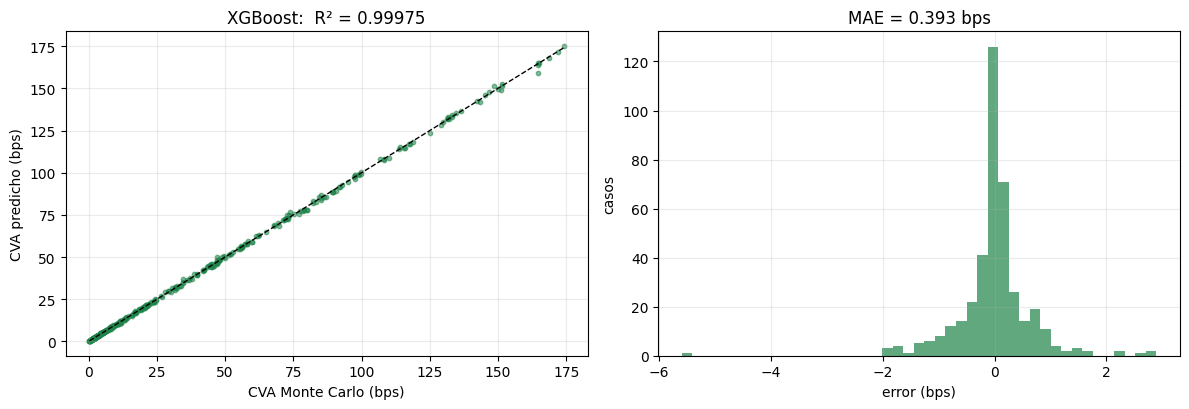

etiquetas: 4.9 s   |   entrenamiento: 0.19 s


In [10]:
def cva_exacto(cds, K):
    """CVA del motor para el spread `cds` y la tasa fija `K`, reutilizando el cubo (P_n y anualidad)
    sin volver a simular."""
    EEk = np.array([np.maximum(Noc*((1-Pn) - K*an), 0).mean() for Pn, an in zip(Pn_l, ann_l)])
    return xva_bps(EEk, cds)

rng = np.random.default_rng(7)
Xtr = np.column_stack([rng.uniform(50, 900, 5000), K_atm*rng.uniform(0.6, 1.4, 5000)])
t0 = time.perf_counter(); ytr = np.array([cva_exacto(c, k) for c, k in Xtr]); t_lab = time.perf_counter()-t0

try:
    from xgboost import XGBRegressor
    modelo, nombre = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=.06), 'XGBoost'
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    modelo, nombre = (HistGradientBoostingRegressor(max_iter=600, learning_rate=.06,
                        max_leaf_nodes=63), 'HistGradientBoosting')
t0 = time.perf_counter(); modelo.fit(Xtr, ytr); t_fit = time.perf_counter()-t0

from sklearn.metrics import r2_score
Xte = np.column_stack([rng.uniform(50, 900, 400), K_atm*rng.uniform(0.6, 1.4, 400)])
yte, yp = np.array([cva_exacto(c, k) for c, k in Xte]), None
yp = modelo.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(yte, yp, s=10, alpha=.55, color='#1e8449')
lims = [yte.min(), yte.max()]; axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set(xlabel='CVA Monte Carlo (bps)', ylabel='CVA predicho (bps)',
            title=f'{nombre}:  R² = {r2_score(yte, yp):.5f}')
axes[1].hist(yp - yte, bins=45, color='#1e8449', alpha=.7)
axes[1].set(xlabel='error (bps)', ylabel='casos',
            title=f'MAE = {np.abs(yp-yte).mean():.3f} bps')
plt.tight_layout(); plt.show()
print(f"etiquetas: {t_lab:.1f} s   |   entrenamiento: {t_fit:.2f} s")

> **Lectura.** **R² por encima de 0.999 y error medio de unas décimas de punto base** (los valores exactos
> cambian ligeramente entre versiones de XGBoost). El sustituto reproduce muy bien al motor, y los
> errores están centrados en cero (sin sesgo sistemático apreciable).
>
> Las etiquetas salieron del propio motor, sin
> etiquetado manual: las 5,000 etiquetas costaron unos cuantos segundos (ver arriba)
> porque el cubo de trayectorias ya estaba en memoria.
>
> Dos observaciones. Primero, **las colas** del histograma: el error no es uniforme, y
> conviene medirlo por región del dominio para saber dónde pierde precisión el modelo. Segundo,
> entrenamos y probamos **con el mismo cubo** de simulación: eso mide qué tan bien aprende esa
> superficie numérica, no su estabilidad ante nuevas simulaciones o nuevas condiciones de mercado.
> En valores entre los nodos de la parrilla de entrenamiento, dentro de sus rangos, la tesis encontró
> que XGBoost multiplica su error
> (MAE de 4.43 bps frente a 0.50) y la red neuronal no (0.66 bps). Por eso, en producción, se
> define un *dominio de validez* para el modelo.

### Lo que el sustituto habilita: 14,400 valuaciones instantáneas
Un mapa completo del CVA en función del riesgo de la contraparte y del *moneyness* del *swap*.
Con el motor Monte Carlo, resimulando en cada valuación, tomaría órdenes de magnitud más tiempo.

### Apunte · El mapa del CVA

Se evalúa el sustituto en una malla de $120 \times 120$ puntos $(s, K)$ con una sola llamada
(predicción en lote) y se dibujan curvas de nivel.

- Como cada árbol es constante por tramos, el mapa hereda escalones. Derivar esa superficie para
  obtener sensibilidades da resultados poco confiables.
- El título compara con el tiempo estimado de resimular cada punto: $t_{\text{sim}} + t_{\text{val}}$
  por valuación, medido en las celdas anteriores.

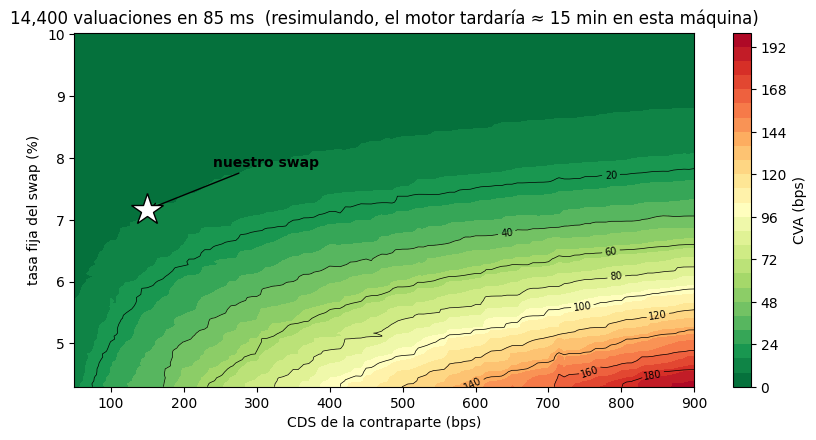

In [11]:
cg = np.linspace(50, 900, 120); kg = K_atm*np.linspace(0.6, 1.4, 120)
CG, KG = np.meshgrid(cg, kg)
t0 = time.perf_counter()
Z = modelo.predict(np.column_stack([CG.ravel(), KG.ravel()])).reshape(CG.shape)
t_mapa = time.perf_counter() - t0

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.contourf(CG, 100*KG, Z, levels=24, cmap='RdYlGn_r')
cs = ax.contour(CG, 100*KG, Z, levels=9, colors='k', linewidths=.5); ax.clabel(cs, fontsize=7)
ax.plot(cds_ella, 100*K_atm, '*', ms=24, color='white', markeredgecolor='k', zorder=5)
ax.annotate('nuestro swap', xy=(cds_ella, 100*K_atm), xytext=(cds_ella+90, 100*K_atm+0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontweight='bold')
plt.colorbar(im, label='CVA (bps)')
ax.set(xlabel='CDS de la contraparte (bps)', ylabel='tasa fija del swap (%)',
       title=f'{CG.size:,} valuaciones en {t_mapa*1000:.0f} ms  '
             f'(resimulando, el motor tardaría ≈ {CG.size*(t_sim + t_val)/60:.0f} min en esta máquina)')
ax.grid(False); plt.show()

> **Lectura.** 14,400 valuaciones en una fracción de segundo. Con el motor, resimulando cada vez, serían
> **minutos** (el título da la estimación en esta máquina).
> Con el sustituto es práctico explorar todo el espacio de escenarios.
>
> Leyendo el mapa: el CVA crece hacia la derecha (peor crédito) y hacia abajo (*swap* más dentro
> del dinero). Las curvas de nivel se curvan porque **los dos efectos se multiplican**:
> el impacto del crédito es mayor cuando la exposición ya es alta.
>
> Las curvas de nivel son escalones, no líneas suaves: es el efecto de los
> *splits* discretos del árbol. Predice el nivel con altísima precisión, pero su derivada es cero
> dentro de cada hoja. Es coherente con lo que encontró la tesis: XGBoost falla en *sensibilidades*
> (error de 33.2% en CS01 y de 545.7% en el PV01 del PC2, con signo invertido), así que para ellas se usa
> una regresión Ridge local, válida sólo dentro de su dominio de entrenamiento, y el *boosting* se
> reserva para el nivel. El modelo adecuado depende del uso.

---
## 7 · La carrera

### Apunte · Cómo se miden los tiempos

- **Motor completo:** una ejecución que simula 10,000 trayectorias, construye el cubo, calcula EE y
  el CVA.
- **Motor con cubo guardado:** sólo `cva_exacto`, que revalúa con $s$ y $K$ nuevos; promedio de 200
  llamadas tras una de calentamiento.
- **Sustituto, una consulta:** `predict` de una fila; promedio de 200 llamadas. Incluye el costo fijo
  de cada llamada.
- **Sustituto en lote:** `predict` de 200,000 filas, dividido entre 200,000.

**Punto de equilibrio** frente al motor completo:

$$n^* = \frac{t_{\text{etiquetas}} + t_{\text{entrenamiento}}}{t_{\text{motor}} - t_{\text{sustituto}}}.$$

Son tiempos de reloj: varían entre máquinas y entre corridas.

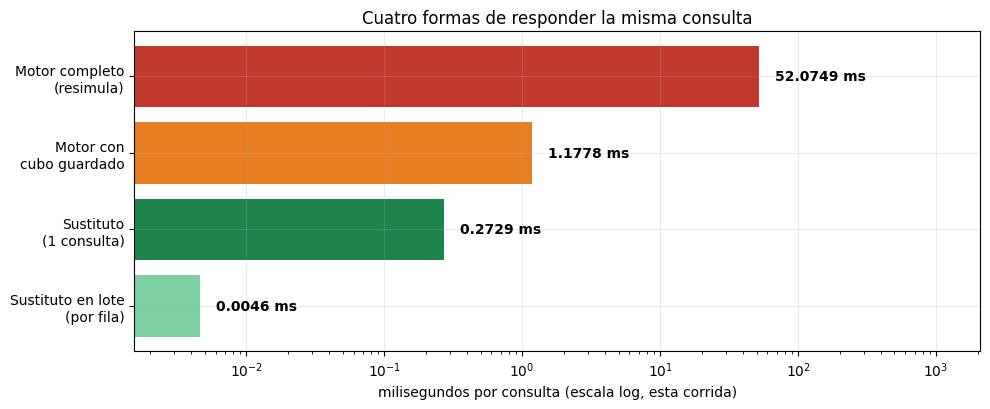

Motor completo ÷ sustituto (1 consulta): 191 veces
Motor con cubo ÷ sustituto (1 consulta): 4.3 veces (mayor que 1: gana el sustituto; menor que 1: gana el motor)
Punto de equilibrio frente al motor completo: ≈ 99 consultas (costo de etiquetar y entrenar ÷ ahorro por consulta)

[Tesis: en su configuración (cinco variables, varios plazos y niveles de curva), los sustitutos
 son de 10^3 a 10^5 veces más rápidos que el motor completo, en promedio por consulta al valuar
 en lote. Son tiempos de reloj en una sola máquina, varían entre corridas y no incluyen el entrenamiento.]


In [12]:
def mide(f, n=200):
    """Tiempo promedio por llamada (s): una llamada de calentamiento y luego n repeticiones."""
    f(); t0 = time.perf_counter()
    for _ in range(n): f()
    return (time.perf_counter() - t0) / n

# (1) Motor completo: resimular, revaluar y agregar, para una sola consulta.
t0 = time.perf_counter()
xr, yr = simular(N=10_000)
Pn_r, an_r = [], []
for jj, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, xr[:, jj], yr[:, jj]) for Tj in rem], axis=1)
    Pn_r.append(Pm[:, -1]); an_r.append(delta*Pm.sum(axis=1))
EEr = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_r, an_r)])
_ = xva_bps(EEr, cds_ella)
t_mc = time.perf_counter() - t0

# (2) Motor con el cubo guardado: sólo cambian el spread o la tasa fija, no hay que resimular.
t_cubo = mide(lambda: cva_exacto(cds_ella, K_atm))

# (3) Sustituto, una consulta a la vez: la latencia que vive quien pregunta una cosa por vez.
x1 = np.array([[cds_ella, K_atm]])
t_ml1 = mide(lambda: modelo.predict(x1))

# (4) Sustituto en lote: costo promedio por fila al valuar 200,000 consultas juntas.
Xq = np.column_stack([np.full(200_000, cds_ella), np.full(200_000, K_atm)])
t0 = time.perf_counter(); modelo.predict(Xq); t_lote = (time.perf_counter() - t0)/200_000

etiquetas = ['Motor completo\n(resimula)', 'Motor con\ncubo guardado',
             'Sustituto\n(1 consulta)', 'Sustituto en lote\n(por fila)']
ms = np.array([t_mc, t_cubo, t_ml1, t_lote])*1000
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(etiquetas, ms, color=['#c0392b', '#e67e22', '#1e8449', '#7dcea0'])
ax.set_xscale('log'); ax.invert_yaxis(); ax.set_xlim(ms.min()/3, ms.max()*40)
for i, v in enumerate(ms):
    ax.text(v*1.3, i, f'{v:,.4f} ms', va='center', fontweight='bold')
ax.set(xlabel='milisegundos por consulta (escala log, esta corrida)',
       title='Cuatro formas de responder la misma consulta')
plt.tight_layout(); plt.show()

print(f"Motor completo ÷ sustituto (1 consulta): {t_mc/t_ml1:,.0f} veces")
print(f"Motor con cubo ÷ sustituto (1 consulta): {t_cubo/t_ml1:,.1f} veces "
      "(mayor que 1: gana el sustituto; menor que 1: gana el motor)")
print(f"Punto de equilibrio frente al motor completo: ≈ {(t_lab + t_fit)/(t_mc - t_ml1):,.0f} consultas "
      "(costo de etiquetar y entrenar ÷ ahorro por consulta)")
print("\n[Tesis: en su configuración (cinco variables, varios plazos y niveles de curva), los sustitutos\n"
      " son de 10^3 a 10^5 veces más rápidos que el motor completo, en promedio por consulta al valuar\n"
      " en lote. Son tiempos de reloj en una sola máquina, varían entre corridas y no incluyen el entrenamiento.]")


> **Lectura.** La comparación incluye cuatro casos:
>
> - **Motor completo:** resimula y revalúa. Es el costo cuando la consulta obliga a simular de nuevo.
> - **Motor con cubo guardado:** en esta demo, el *spread* y la tasa fija se cambian sin resimular,
>   así que el motor ya es rápido. Frente a él, la ventaja del sustituto es pequeña o puede no
>   existir, según la máquina.
> - **Sustituto, una consulta:** la latencia de quien pregunta una cosa a la vez; incluye el costo
>   fijo de cada llamada.
> - **Sustituto en lote:** el costo promedio por fila al valuar muchas consultas juntas. Es la cifra
>   más baja, pero no es la latencia de una consulta individual.
>
> En resumen: este sustituto aprende una superficie de dos variables (*spread* y tasa fija), que el
> motor también resuelve con el cubo guardado. Los sustitutos de la tesis reciben además plazo y
> nivel de curva; su ventaja se mide frente al mejor motor reutilizable en cada caso. Ninguna barra incluye generar las etiquetas ni entrenar; la celda
> calcula cuántas consultas hacen falta para recuperar ese costo frente al motor completo. Para una
> consulta aislada, el Monte Carlo sigue siendo más barato de extremo a extremo.

---
## 8 · Cotización *pre-deal* en tiempo real
Un cliente pide cotización. La mesa calcula el CVA de **varias alternativas** mientras atiende la
consulta.

### Apunte · La cotización *pre-deal*

Cinco consultas: tres contrapartes con la tasa ATM y dos variantes del cliente B, con
$K = 0.97\,K_{\text{ATM}}$ y $K = 1.03\,K_{\text{ATM}}$ (unos 21 bps por debajo y por encima). Para
un *payer*, una tasa fija menor deja el *swap* dentro del dinero y aumenta la exposición.

Para cada consulta se compara la predicción del sustituto con el CVA del motor (cubo guardado) y se
reporta la diferencia en bps y el monto en pesos, $\mathrm{CVA}_{\text{bps}} \times N_{\text{noc}} / 10^4$.

In [13]:
escenarios = [('Cliente A: banco grande',      180, K_atm),
              ('Cliente B: corporativo mediano', 520, K_atm),
              ('Cliente B, swap ~20 bps ITM',   520, K_atm*0.97),
              ('Cliente B, swap ~20 bps OTM',   520, K_atm*1.03),
              ('Cliente C: contraparte frágil', 900, K_atm)]

t0 = time.perf_counter()
pred = [modelo.predict(np.array([[c, k]]))[0] for _, c, k in escenarios]
t_todo = time.perf_counter() - t0
t0 = time.perf_counter()
exacto = [cva_exacto(c, k) for _, c, k in escenarios]        # verificación contra el motor (cubo guardado)
t_ver = time.perf_counter() - t0

print(f"{'Escenario':<32}{'CDS':>5}{'K':>8}{'ML':>9}{'motor':>9}{'dif':>7}{'MXN':>12}")
print('─'*82)
for (n, c, k), p, e in zip(escenarios, pred, exacto):
    print(f"{n:<32}{c:>5.0f}{k:>8.2%}{p:>8.2f}{e:>9.2f}{p-e:>+7.2f}{p/1e4*Noc:>12,.0f}")
print('─'*82)
print(f"Las {len(escenarios)} cotizaciones: sustituto {t_todo*1000:.1f} ms; motor con cubo guardado "
      f"{t_ver*1000:.1f} ms; motor resimulando ≈ {len(escenarios)*t_mc:.2f} s.")
print("\nVerificación contra el motor: con cinco consultas no se concluye dónde falla el modelo;\n"
      "eso se mide por región del dominio y entre los nodos de la parrilla de entrenamiento.")
print("En producción, esa reconciliación es parte indispensable del gobierno del modelo.")

Escenario                         CDS       K       ML    motor    dif         MXN
──────────────────────────────────────────────────────────────────────────────────
Cliente A: banco grande           180   7.16%    9.00     9.10  -0.10       9,000
Cliente B: corporativo mediano    520   7.16%   23.92    23.97  -0.05      23,921
Cliente B, swap ~20 bps ITM       520   6.95%   27.76    28.98  -1.22      27,756
Cliente B, swap ~20 bps OTM       520   7.38%   20.81    19.72  +1.09      20,812
Cliente C: contraparte frágil     900   7.16%   36.69    37.53  -0.85      36,689
──────────────────────────────────────────────────────────────────────────────────
Las 5 cotizaciones: sustituto 3.2 ms; motor con cubo guardado 7.3 ms; motor resimulando ≈ 0.26 s.

Verificación contra el motor: con cinco consultas no se concluye dónde falla el modelo;
eso se mide por región del dominio y entre los nodos de la parrilla de entrenamiento.
En producción, esa reconciliación es parte indispensable del gobiern

> **Lectura.** Cinco alternativas cotizadas en milisegundos.
>
> Efecto del *moneyness*: según el motor, el mismo cliente B paga **unos 29 bps** si el
> *swap* está dentro del dinero y **unos 20 bps** si está fuera. El CVA no depende sólo de *quién* es
> la contraparte, sino de *cuánto* te va a deber.
>
> En la columna "dif", el error va de centésimas a alrededor de 1 bp. Con cinco
> consultas no se puede concluir dónde pierde precisión el modelo: para eso se evalúa el error por
> región del dominio, y entre los nodos de la parrilla de entrenamiento, que es donde la tesis encontró las
> diferencias grandes. Por eso la reconciliación periódica contra el motor es parte indispensable del
> gobierno del modelo.
>
> En esta demo, el motor con el cubo guardado también responde estas consultas en
> milisegundos, porque sólo cambian el *spread* y la tasa fija. Este sustituto sólo recibe *spread* y tasa fija;
> los sustitutos de la tesis, con plazo y nivel de curva como variables, son los que evitan resimular.

---
## Lo que falta para producción

Curva completa de Valmer y *bootstrap* de CDS reales · calibración a la superficie de *swaptions* ·
portafolio con *netting* por contraparte · CVA incremental *pre-deal* · sensibilidades (PV01, CS01)
para cobertura · reporte mensual del Formulario XVA de Banxico · atribución por operación · validación, dominio de validez y
gobierno del modelo.

*Parámetros del G2++: calibrados en la tesis «Comparación de métodos numéricos para el cálculo de CVA
en swaps de tasas de interés» a swaptions ATM (Bloomberg SWPM, 24-mar-2026). Nivel de tasa y spreads:
supuestos ilustrativos de la demo. Recuperación: convención de CDS para mercados emergentes (Iwashita, 2013).*

---
## Apunte final · Formulario

| Concepto | Fórmula |
|---|---|
| Tasa corta G2++ | $r(t) = x(t) + y(t) + \varphi(t)$ |
| Factores | $dx = -a\,x\,dt + \sigma\,dW_1$, $\;dy = -b\,y\,dt + \eta\,dW_2$, $\;dW_1 dW_2 = \rho\,dt$ |
| Transición exacta | $x_{t+\Delta} = x_t e^{-a\Delta} + \sigma\sqrt{(1-e^{-2a\Delta})/(2a)}\,Z_1$ |
| Bono cupón cero | $P(t,T) = \frac{P^M(0,T)}{P^M(0,t)}\,e^{\frac12[V(t,T)-V(0,T)+V(0,t)] - B_a x - B_b y}$ |
| Factor $B$ | $B_k(\tau) = (1-e^{-k\tau})/k$ |
| *Swap payer* | $V(t_i) = N_{\text{noc}}\,[\,1 - P(t_i,T_n) - K\,\delta\sum_{T_j>t_i} P(t_i,T_j)\,]$ |
| Tasa ATM | $K_{\text{ATM}} = (1 - P(0,T_n)) / (\delta \sum_j P(0,T_j))$ |
| Exposiciones | $\mathrm{EE} = \mathbb{E}[\max(V,0)]$, $\;\mathrm{ENE} = \mathbb{E}[\max(-V,0)]$ |
| Intensidad | $\lambda \approx s/(1-R)$, $\;Q(t) = e^{-\lambda t}$ |
| CVA | $(1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}_i\,\mathrm{DF}(t_i)$ |
| DVA | $(1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}^{\text{propia}}_i\,\mathrm{DF}(t_i)$ |
| Ajuste bilateral simplificado | $\mathrm{BCVA} = \mathrm{DVA} - \mathrm{CVA}$ |
| Error de Monte Carlo | $\propto 1/\sqrt{N}$ |
| *Boosting* | $F_M = F_0 + \nu \sum_m h_m$ |
| Métricas | $R^2 = 1 - \mathrm{SSE}/\mathrm{SST}$, $\;\mathrm{MAE} = \frac1n\sum \lvert y-\hat y\rvert$ |

**Referencias:** Brigo y Mercurio (2006), *Interest Rate Models: Theory and Practice*; Gregory
(2012), *Counterparty Credit Risk and Credit Value Adjustment*; Chen y Guestrin (2016), *XGBoost: A
Scalable Tree Boosting System*.